In [11]:
from langchain_groq import ChatGroq
from langchain.schema import HumanMessage, AIMessage
from langgraph.graph import StateGraph, END
from neo4j import GraphDatabase
import os



In [ ]:
NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "password"
GROQ_API_KEY = "your_groq_api_key"

In [4]:
llm.invoke("hello")

AIMessage(content='Hello! 👋 \n\nHow can I help you today?\n', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 11, 'total_tokens': 26, 'completion_time': 0.027272727, 'prompt_time': 0.001867395, 'queue_time': 0.24202626500000002, 'total_time': 0.029140122}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--5dc04339-bea1-492c-bcaf-5d072992d33d-0', usage_metadata={'input_tokens': 11, 'output_tokens': 15, 'total_tokens': 26})

In [7]:
import os
from typing import List
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END
from neo4j import GraphDatabase
from datetime import datetime

# Neo4j connection setup
NEO4J_URI = "neo4j://127.0.0.1:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "password"
GROQ_API_KEY = "your-groq-api-key"

# Initialize Neo4j driver
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

# Initialize ChatGroq
llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model="mixtral-8x7b-32768",
    temperature=0.7
)

def setup_neo4j_constraints():
    """Create necessary Neo4j constraints and indexes"""
    with driver.session() as session:
        # Create constraints
        session.run("""
            CREATE CONSTRAINT session_constraint IF NOT EXISTS 
            FOR (s:Session) REQUIRE s.id IS UNIQUE
        """)
        
        session.run("""
            CREATE CONSTRAINT message_constraint IF NOT EXISTS 
            FOR (m:Message) REQUIRE m.id IS UNIQUE
        """)

def store_message(content: str, role: str, session_id: str, message_index: int):
    """Store a message in Neo4j"""
    message_id = f"{session_id}_{message_index}"
    
    with driver.session() as session:
        session.run("""
            MERGE (s:Session {id: $session_id})
            CREATE (m:Message {
                id: $message_id,
                content: $content,
                role: $role,
                index: $message_index,
                timestamp: datetime()
            })
            CREATE (s)-[:CONTAINS]->(m)
        """, 
        session_id=session_id,
        message_id=message_id,
        content=content,
        role=role,
        message_index=message_index
        )

def load_session_messages(session_id: str, limit: int = 20) -> List[BaseMessage]:
    """Load previous messages from Neo4j for a session"""
    with driver.session() as session:
        result = session.run("""
            MATCH (s:Session {id: $session_id})-[:CONTAINS]->(m:Message)
            RETURN m.content as content, m.role as role, m.index as msg_index
            ORDER BY m.index
            LIMIT $limit
        """, session_id=session_id, limit=limit)
        
        messages = []
        for record in result:
            if record["role"] == "user":
                messages.append(HumanMessage(content=record["content"]))
            elif record["role"] == "ai":
                messages.append(AIMessage(content=record["content"]))
        
        return messages

class AgentState(dict): 
    """Simple state class that extends dict"""
    pass

def load_memory_step(state: AgentState) -> AgentState:
    """Load previous conversation history from Neo4j"""
    session_id = state.get("session_id", "chatgroq_demo")
    current_messages = state.get("messages", [])
    
    # Load previous messages from Neo4j
    previous_messages = load_session_messages(session_id)
    
    # Combine previous messages with current input
    # Only add previous messages if we have new input
    if current_messages and previous_messages:
        # Remove the current message temporarily
        current_input = current_messages[-1]
        all_messages = previous_messages + [current_input]
    else:
        all_messages = current_messages
    
    return AgentState(messages=all_messages, session_id=session_id)

def agent_step(state: AgentState) -> AgentState:
    """Main agent processing step"""
    messages = state.get("messages", [])
    session_id = state.get("session_id", "chatgroq_demo")

    if not messages:
        raise ValueError("No input messages provided to the agent.")

    # Get the latest user message
    user_msg = messages[-1]
    
    # Store user message (only if it's new)
    user_message_index = len([m for m in messages if isinstance(m, (HumanMessage, AIMessage))]) - 1
    store_message(user_msg.content, "user", session_id, user_message_index)

    # Get AI response
    ai_msg = llm.invoke(messages)
    
    # Store AI message
    ai_message_index = len([m for m in messages if isinstance(m, (HumanMessage, AIMessage))])
    store_message(ai_msg.content, "ai", session_id, ai_message_index)

    # Add AI response to messages
    messages.append(ai_msg)
    
    return AgentState(messages=messages, session_id=session_id)

# Create the agent graph (do this once)
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("load_memory", load_memory_step)
workflow.add_node("agent", agent_step)

# Define the flow
workflow.set_entry_point("load_memory")
workflow.add_edge("load_memory", "agent")
workflow.add_edge("agent", END)

# Compile the graph
graph = workflow.compile()

# Setup Neo4j constraints (run this once)
setup_neo4j_constraints()

print("🤖 Agent setup complete! Ready to use graph.invoke()")
print("Example usage:")
print("state = AgentState(messages=[HumanMessage('Hello!')], session_id='my_session')")
print("result = graph.invoke(state)")
print("print(result['messages'][-1].content)")

# Notebook-friendly helper function
def create_state(message: str, session_id: str = "notebook_session"):
    """Helper to create initial state for notebook usage"""
    return AgentState(
        messages=[HumanMessage(content=message)],
        session_id=session_id
    )

# Example for notebook usage
print("\n=== Quick Test ===")
# Test the setup


🤖 Agent setup complete! Ready to use graph.invoke()
Example usage:
state = AgentState(messages=[HumanMessage('Hello!')], session_id='my_session')
result = graph.invoke(state)
print(result['messages'][-1].content)

=== Quick Test ===


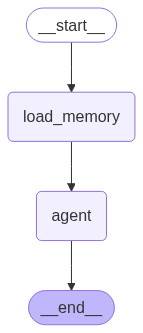

In [9]:
graph

In [8]:
test_state = create_state("Hi, I'm testing the agent setup!")
result = graph.invoke(test_state)
print(f"Agent: {result['messages'][-1].content}")

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: role)} {position: line: 3, column: 44, offset: 117} for query: '\n            MATCH (s:Session {id: $session_id})-[:CONTAINS]->(m:Message)\n            RETURN m.content as content, m.role as role, m.index as msg_index\n            ORDER BY m.index\n            LIMIT $limit\n        '
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not ava

ValueError: No input messages provided to the agent.

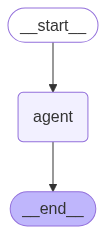

In [11]:
graph1

In [12]:
result = graph1.invoke({
    "messages": [HumanMessage(content="Who is the president of inda?")],
    "session_id": "session_001"
})

for msg in result["messages"]:
    print(f"[{msg.type.upper()}]: {msg.content}")


ValueError: No input messages provided to the agent.

In [1]:
from langchain_core.messages import HumanMessage, AIMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph
from neo4j import GraphDatabase

# Set up Groq
llm = ChatGroq(model_name="Gemma2-9b-It")

# Set up Neo4j
driver = GraphDatabase.driver("neo4j://127.0.0.1:7687", auth=("neo4j", "password"))

def store_message(content, role, session_id, index):
    message_id = f"{session_id}_{index}"
    with driver.session() as session:
        session.run("""
            MERGE (m:Message {id: $message_id})
            SET m.content = $content, m.role = $role, m.timestamp = timestamp()
            MERGE (s:Session {id: $session_id})
            MERGE (s)-[:HAS_MESSAGE]->(m)
            WITH m
            OPTIONAL MATCH (prev:Message {id: $previous_id})
            WHERE $previous_id IS NOT NULL
            MERGE (prev)-[:NEXT]->(m)
        """, content=content, role=role, session_id=session_id, message_id=message_id,
           previous_id=None if index == 0 else f"{session_id}_{index-1}")

# Define AgentState and step




In [2]:
import uuid
message_id = str(uuid.uuid4())

In [3]:
import uuid
class AgentState(dict):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.setdefault("session_id", f"session_{uuid.uuid4().hex[:8]}")
        self.setdefault("messages", [])


In [4]:


def agent_step(state: AgentState) -> AgentState:
    # Validate input
    if not state["messages"] or not isinstance(state["messages"][-1], HumanMessage):
        raise ValueError("Last message must be from user")
    
    # Create copy of state for modification
    new_state = AgentState(state)
    
    # Store user message
    store_message(
        content=new_state["messages"][-1].content,
        role="user",
        session_id=new_state["session_id"],
        index=len(new_state["messages"])-1
    )
    
    # Generate response
    ai_msg = llm.invoke(new_state["messages"])
    
    # Store AI message
    store_message(
        content=ai_msg.content,
        role="ai",
        session_id=new_state["session_id"],
        index=len(new_state["messages"])
    )
    
    # Update state
    new_state["messages"] = new_state["messages"] + [ai_msg]
    return new_state

# Build the graph
builder = StateGraph(AgentState)
builder.add_node("agent", agent_step)
builder.set_entry_point("agent")
builder.set_finish_point("agent")
graph1 = builder.compile()



In [5]:
# Run the agent
result = graph1.invoke({
    "messages": [HumanMessage(content="Who is the president of India?")],
    "session_id": "session_001"
})



KeyError: 'messages'

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph
from neo4j import GraphDatabase
import uuid

class AgentState(dict):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.setdefault("session_id", f"session_{uuid.uuid4().hex[:8]}")
        self.setdefault("messages", [])

def agent_step(state: AgentState) -> AgentState:
    # Validate input
    if not state["messages"] or not isinstance(state["messages"][-1], HumanMessage):
        raise ValueError("Last message must be from user")
    
    # Create copy of state for modification
    new_state = AgentState(state)
    
    # Store user message
    store_message(
        content=new_state["messages"][-1].content,
        role="user",
        session_id=new_state["session_id"],
        index=len(new_state["messages"])-1
    )
    
    # Generate response
    ai_msg = llm.invoke(new_state["messages"])
    
    # Store AI message
    store_message(
        content=ai_msg.content,
        role="ai",
        session_id=new_state["session_id"],
        index=len(new_state["messages"])
    )
    
    # Update state
    new_state["messages"] = new_state["messages"] + [ai_msg]
    return new_state
